In [17]:
# ================================================================
# HyperCLAP — Validation 2 : Cross-Dataset (UrbanSound8K)
#
# Objectif : montrer que le mécanisme tient sur un dataset
# différent d'ESC-50 — distribution acoustique différente,
# 10 classes de sons urbains, enregistrements in-the-wild.
#
# Fix vs version précédente :
#   - Resample tout vers SR_TARGET=22050 avant stockage
#   - target_len calculé une seule fois → longueurs uniformes
# ================================================================

In [18]:
!pip install -q datasets soundfile librosa
print("done")

done


In [19]:
import numpy as np
import librosa
import random
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict
from datasets import load_dataset
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

SR_TARGET       = 22050          # sr uniforme — tous les clips resamplés ici
TARGET_LEN      = 4 * SR_TARGET  # 88200 samples = 4s exactement

CFG = dict(
    n_mels=128, n_fft=1024, hop_length=512,
    k=4, d=64, tau=0.1, lr=3e-4, batch_size=32,
)
TARGET_T        = 128
EPOCHS_P1       = 60
EPOCHS_P2       = 60
N_MIX_TEST      = 400
CLIPS_PER_CLASS = 40

Device: cuda


In [20]:
# ── Charger UrbanSound8K ─────────────────────────────────────────
print("Loading UrbanSound8K...")
urban      = load_dataset("danavery/urbansound8K", trust_remote_code=True)
urban_data = urban["train"]
print(f"Total clips : {len(urban_data)}")
print(f"Classes     : {sorted(set(urban_data['class']))}")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'danavery/urbansound8K' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loading UrbanSound8K...
Total clips : 8732
Classes     : ['air_conditioner', 'car_horn', 'children_playing', 'dog_bark', 'drilling', 'engine_idling', 'gun_shot', 'jackhammer', 'siren', 'street_music']


In [21]:
# ── Corpus équilibré + préprocessing ────────────────────────────
classes   = sorted(set(urban_data["class"]))
class2idx = {c: i for i, c in enumerate(classes)}
N_CLASSES = len(classes)

by_class = defaultdict(list)
for i, sample in enumerate(urban_data):
    by_class[sample["class"]].append(i)

selected_indices = []
for cls in classes:
    idx = by_class[cls][:]
    random.shuffle(idx)
    selected_indices.extend(idx[:CLIPS_PER_CLASS])

print(f"\nClasses ({N_CLASSES}) : {classes}")
print(f"Corpus             : {len(selected_indices)} clips")
print(f"SR cible           : {SR_TARGET} Hz")
print(f"Longueur cible     : {TARGET_LEN} samples (4s)\n")

print("Pre-computing log-mel spectrograms...")
all_logmels  = []
all_waveforms = []
all_labels   = []

for i, idx in enumerate(selected_indices):
    sample = urban_data[idx]
    w  = np.array(sample["audio"]["array"], dtype=np.float32)
    sr = sample["audio"]["sampling_rate"]

    # 1. Resample vers SR_TARGET — garantit sr identique pour tous
    if sr != SR_TARGET:
        w = librosa.resample(w, orig_sr=sr, target_sr=SR_TARGET)

    # 2. Normaliser la longueur — TARGET_LEN est fixe car sr est fixe
    if len(w) > TARGET_LEN:
        w = w[:TARGET_LEN]
    elif len(w) < TARGET_LEN:
        w = np.pad(w, (0, TARGET_LEN - len(w)))

    # 3. Log-mel
    mel = librosa.feature.melspectrogram(
        y=w, sr=SR_TARGET,
        n_fft=CFG["n_fft"], hop_length=CFG["hop_length"], n_mels=CFG["n_mels"])
    lm = librosa.power_to_db(mel, ref=np.max)

    all_logmels.append(lm)
    all_waveforms.append((w, SR_TARGET))   # longueur garantie = TARGET_LEN
    all_labels.append(class2idx[sample["class"]])

    if (i + 1) % 80 == 0:
        print(f"  {i+1}/{len(selected_indices)}")

N_reduced = len(selected_indices)
print(f"Done. N_reduced={N_reduced}\n")

# Vérification longueurs
lens = [len(w) for w, _ in all_waveforms]
assert len(set(lens)) == 1, f"Longueurs non uniformes : {set(lens)}"
print(f"Longueur uniforme confirmée : {lens[0]} samples\n")


Classes (10) : ['air_conditioner', 'car_horn', 'children_playing', 'dog_bark', 'drilling', 'engine_idling', 'gun_shot', 'jackhammer', 'siren', 'street_music']
Corpus             : 400 clips
SR cible           : 22050 Hz
Longueur cible     : 88200 samples (4s)

Pre-computing log-mel spectrograms...
  80/400
  160/400
  240/400
  320/400
  400/400
Done. N_reduced=400

Longueur uniforme confirmée : 88200 samples



In [22]:
# ── Helpers ──────────────────────────────────────────────────────
def logmel_to_tensor(lm):
    lm = (lm - lm.min()) / (lm.max() - lm.min() + 1e-8) * 2 - 1
    return torch.tensor(lm, dtype=torch.float32)

def pool_mel(t, T=TARGET_T):
    return F.adaptive_avg_pool2d(t.unsqueeze(0), (t.shape[0], T)).squeeze(0)

def normalize_w(w):
    n = np.linalg.norm(w); return w / n if n > 1e-8 else w

In [23]:
# ── Architecture ─────────────────────────────────────────────────
class SubspaceEncoder(nn.Module):
    def __init__(self, d=64, k=4):
        super().__init__()
        self.d = d; self.k = k
        self.cnn = nn.Sequential(
            nn.Conv2d(1,16,3,padding=1), nn.BatchNorm2d(16), nn.GELU(), nn.MaxPool2d(2),
            nn.Conv2d(16,32,3,padding=1), nn.BatchNorm2d(32), nn.GELU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.GELU(), nn.AdaptiveAvgPool2d((4,4)),
        )
        self.proj = nn.Sequential(nn.Linear(1024,256), nn.GELU(), nn.Linear(256, d*k))
    def forward(self, x):
        B = x.shape[0]
        h = self.cnn(x.unsqueeze(1)).view(B, -1)
        z = self.proj(h).view(B, self.d, self.k)
        Z, _ = torch.linalg.qr(z)
        return Z

class PointEncoder(nn.Module):
    def __init__(self, d=64):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1,16,3,padding=1), nn.BatchNorm2d(16), nn.GELU(), nn.MaxPool2d(2),
            nn.Conv2d(16,32,3,padding=1), nn.BatchNorm2d(32), nn.GELU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.GELU(), nn.AdaptiveAvgPool2d((4,4)),
        )
        self.proj = nn.Sequential(nn.Linear(1024,256), nn.GELU(), nn.Linear(256,d))
    def forward(self, x):
        B = x.shape[0]
        return F.normalize(self.proj(self.cnn(x.unsqueeze(1)).view(B,-1)), dim=-1)

In [24]:
# ── Losses ───────────────────────────────────────────────────────
def subspace_sim_matrix(Z1, Z2):
    M = torch.einsum("inp,jnq->ijpq", Z1, Z2)
    return (M**2).sum(dim=(2,3)) / Z1.shape[2]

def subspace_sim_batch(Z1, Z2):
    M = torch.bmm(Z1.transpose(1,2), Z2)
    return (M**2).sum(dim=(1,2)) / Z1.shape[2]

def infonce_subspace(Za, Zp, tau=0.1):
    B = Za.shape[0]
    return F.cross_entropy(subspace_sim_matrix(Za,Zp)/tau,
                           torch.arange(B, device=Za.device))

def infonce_cosine(za, zp, tau=0.1):
    B = za.shape[0]
    return F.cross_entropy(torch.mm(za,zp.T)/tau,
                           torch.arange(B, device=za.device))

def alignment_loss(Z_mix, Z_a, Z_b, Z_neg_list, margin=0.1):
    pos = (subspace_sim_batch(Z_mix,Z_a) + subspace_sim_batch(Z_mix,Z_b)) / 2
    neg = torch.stack(
        [subspace_sim_batch(Z_mix,Zn) for Zn in Z_neg_list], dim=1
    ).max(1).values
    loss = F.relu(margin + neg - pos).mean()
    return loss, pos.mean().item(), neg.mean().item()

In [25]:
# ── Datasets ─────────────────────────────────────────────────────
class PairDataset(Dataset):
    def __init__(self, logmels, label_ids):
        self.logmels = logmels; self.label_ids = label_ids
        self.by_class = defaultdict(list)
        for i, l in enumerate(label_ids): self.by_class[l].append(i)
    def __len__(self): return len(self.logmels)
    def _t(self, idx): return pool_mel(logmel_to_tensor(self.logmels[idx]))
    def __getitem__(self, idx):
        label = self.label_ids[idx]
        pos   = random.choice([j for j in self.by_class[label] if j != idx])
        return self._t(idx), self._t(pos), label

class MixtureDataset(Dataset):
    def __init__(self, logmels, waveforms, label_ids, n_neg=4):
        self.logmels   = logmels
        self.waveforms = waveforms
        self.label_ids = label_ids
        self.n_neg     = n_neg
        self.by_class  = defaultdict(list)
        for i, l in enumerate(label_ids): self.by_class[l].append(i)
        self.all_classes = list(self.by_class.keys())

    def __len__(self): return len(self.logmels)

    def _t(self, idx):
        return pool_mel(logmel_to_tensor(self.logmels[idx]))

    def _mix_t(self, wa, wb):
        # wa et wb ont la même longueur garantie (TARGET_LEN samples, SR_TARGET Hz)
        mix = (normalize_w(wa) + normalize_w(wb)).astype(np.float32)
        lm  = librosa.feature.melspectrogram(
            y=mix, sr=SR_TARGET,
            n_fft=CFG["n_fft"], hop_length=CFG["hop_length"], n_mels=CFG["n_mels"])
        return pool_mel(logmel_to_tensor(librosa.power_to_db(lm, ref=np.max)))

    def __getitem__(self, idx):
        a_lbl  = self.label_ids[idx]
        others = [c for c in self.all_classes if c != a_lbl]
        b_idx  = random.choice(self.by_class[random.choice(others)])
        wa, _  = self.waveforms[idx]
        wb, _  = self.waveforms[b_idx]

        neg_classes = [c for c in self.all_classes
                       if c not in [a_lbl, self.label_ids[b_idx]]]
        negs = [random.choice(self.by_class[random.choice(neg_classes)])
                for _ in range(self.n_neg)]

        return (self._mix_t(wa, wb),
                self._t(idx), self._t(b_idx),
                torch.stack([self._t(n) for n in negs]),
                idx, b_idx)

In [26]:
# ── Entraînement ─────────────────────────────────────────────────
sub_model = SubspaceEncoder(d=CFG["d"], k=CFG["k"]).to(DEVICE)
pt_model  = PointEncoder(d=CFG["d"]).to(DEVICE)

pair_dl = DataLoader(PairDataset(all_logmels, all_labels),
                     batch_size=CFG["batch_size"], shuffle=True,
                     drop_last=True, num_workers=0)
mix_dl  = DataLoader(MixtureDataset(all_logmels, all_waveforms, all_labels),
                     batch_size=CFG["batch_size"], shuffle=True,
                     drop_last=True, num_workers=0)

sub_opt = torch.optim.Adam(sub_model.parameters(), lr=CFG["lr"])
pt_opt  = torch.optim.Adam(pt_model.parameters(),  lr=CFG["lr"])

print("=" * 60)
print(f"PHASE 1 — InfoNCE ({EPOCHS_P1} epochs) sur UrbanSound8K")
print("=" * 60)
sub_model.train(); pt_model.train()
for epoch in range(EPOCHS_P1):
    ts = 0.0; tp = 0.0; nb = 0
    for anc, pos, _ in pair_dl:
        anc = anc.to(DEVICE); pos = pos.to(DEVICE)
        sub_opt.zero_grad()
        ls = infonce_subspace(sub_model(anc), sub_model(pos), CFG["tau"])
        ls.backward(); sub_opt.step()
        pt_opt.zero_grad()
        lp = infonce_cosine(pt_model(anc), pt_model(pos), CFG["tau"])
        lp.backward(); pt_opt.step()
        ts += ls.item(); tp += lp.item(); nb += 1
    if (epoch+1) % 10 == 0:
        print(f"  Epoch {epoch+1}/{EPOCHS_P1}  sub={ts/nb:.4f}  pt={tp/nb:.4f}")

print(f"\nPHASE 2 — Acoustic alignment ({EPOCHS_P2} epochs)")
sub_opt2 = torch.optim.Adam(sub_model.parameters(), lr=CFG["lr"]/5)
sub_model.train()
for epoch in range(EPOCHS_P2):
    tot = 0.0; nb = 0
    for mix_t, src_a, src_b, neg_ts, ai, bi in mix_dl:
        mix_t  = mix_t.to(DEVICE); src_a = src_a.to(DEVICE)
        src_b  = src_b.to(DEVICE); neg_ts = neg_ts.to(DEVICE)
        sub_opt2.zero_grad()
        Z_mix = sub_model(mix_t)
        with torch.no_grad():
            Z_a = sub_model(src_a); Z_b = sub_model(src_b)
            B, nn_, H, W = neg_ts.shape
            Zn = sub_model(neg_ts.view(B*nn_, H, W))
            Z_neg_list = [Zn[i::nn_] for i in range(nn_)]
        loss, ps, ns = alignment_loss(Z_mix, Z_a, Z_b, Z_neg_list)
        loss.backward(); sub_opt2.step()
        tot += loss.item(); nb += 1
    if (epoch+1) % 10 == 0:
        print(f"  Epoch {epoch+1}/{EPOCHS_P2}  "
              f"align={tot/nb:.4f}  pos={ps:.4f}  neg={ns:.4f}")

print("\nEntraînement terminé.")

PHASE 1 — InfoNCE (60 epochs) sur UrbanSound8K
  Epoch 10/60  sub=2.5227  pt=2.4502
  Epoch 20/60  sub=1.9899  pt=1.9335
  Epoch 30/60  sub=1.7485  pt=1.6285
  Epoch 40/60  sub=1.6049  pt=1.4730
  Epoch 50/60  sub=1.5007  pt=1.4219
  Epoch 60/60  sub=1.4307  pt=1.3784

PHASE 2 — Acoustic alignment (60 epochs)
  Epoch 10/60  align=0.0288  pos=0.6013  neg=0.3236
  Epoch 20/60  align=0.0209  pos=0.5158  neg=0.3036
  Epoch 30/60  align=0.0168  pos=0.5036  neg=0.2650
  Epoch 40/60  align=0.0093  pos=0.4889  neg=0.2303
  Epoch 50/60  align=0.0099  pos=0.5132  neg=0.2657
  Epoch 60/60  align=0.0092  pos=0.5282  neg=0.2817

Entraînement terminé.


In [27]:
# ── Précalcul embeddings ─────────────────────────────────────────
print("Pre-computing embeddings...")
sub_model.eval(); pt_model.eval()
emb_sub = []; emb_pt = []
with torch.no_grad():
    for lm in all_logmels:
        t = pool_mel(logmel_to_tensor(lm)).unsqueeze(0).to(DEVICE)
        emb_sub.append(sub_model(t).squeeze(0).cpu().numpy())
        emb_pt.append(pt_model(t).squeeze(0).cpu().numpy())
mat_sub = np.stack(emb_sub)
mat_pt  = np.stack(emb_pt)
print(f"mat_sub={mat_sub.shape}  mat_pt={mat_pt.shape}\n")

Pre-computing embeddings...
mat_sub=(400, 64, 4)  mat_pt=(400, 64)



In [28]:
# ── Helpers similarité + décomposition ──────────────────────────
def batch_sub_sim(z, mat):
    M = np.einsum("dp,ndq->npq", z, mat)
    return (M**2).sum(axis=(1,2)) / z.shape[1]

def batch_cos_sim(v, mat):
    return (mat @ v) / (np.linalg.norm(mat, axis=1) * np.linalg.norm(v) + 1e-8)

def orth_proj(Z_mix, Z_ref):
    P    = np.eye(Z_mix.shape[0]) - Z_ref @ Z_ref.T
    Q, _ = np.linalg.qr(P @ Z_mix)
    return Q[:, :Z_mix.shape[1]]

def iterative_decomp(Z_mix, mat, ei, ej):
    s1 = batch_sub_sim(Z_mix, mat)
    s1[ei] = s1[ej] = -np.inf
    p1 = int(np.argmax(s1))
    s2 = batch_sub_sim(orth_proj(Z_mix, mat[p1]), mat)
    s2[ei] = s2[ej] = s2[p1] = -np.inf
    return p1, int(np.argmax(s2))

In [29]:
# ── Évaluation ───────────────────────────────────────────────────
print("=" * 65)
print("EXPERIMENT V2: UrbanSound8K — Class-level Decomposition")
print(f"Corpus: {N_reduced} clips  |  {N_MIX_TEST} queries")
print("=" * 65)

KS = [1, 2, 5, 10]
hits_decomp = defaultdict(int)
hits_direct = defaultdict(int)
hits_pt     = defaultdict(int)
both_decomp = 0; both_pt = 0; n_q = 0

for _ in range(N_MIX_TEST):
    i = random.randint(0, N_reduced-1)
    j = random.randint(0, N_reduced-1)
    if i == j: continue

    li = all_labels[i]; lj = all_labels[j]
    wa, _ = all_waveforms[i]
    wb, _ = all_waveforms[j]

    # mélange — longueurs identiques garanties
    mix    = normalize_w(wa) + normalize_w(wb)
    lm_mix = librosa.feature.melspectrogram(
        y=mix, sr=SR_TARGET,
        n_fft=CFG["n_fft"], hop_length=CFG["hop_length"], n_mels=CFG["n_mels"])
    lm_mix = librosa.power_to_db(lm_mix, ref=np.max)
    t_mix  = pool_mel(logmel_to_tensor(lm_mix)).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        Z_mix = sub_model(t_mix).squeeze(0).cpu().numpy()
        v_mix = pt_model(t_mix).squeeze(0).cpu().numpy()

    ss = batch_sub_sim(Z_mix, mat_sub); ss[[i,j]] = -np.inf
    sp = batch_cos_sim(v_mix, mat_pt);  sp[[i,j]] = -np.inf

    ranked_sub = [all_labels[idx] for idx in np.argsort(-ss)]
    ranked_pt  = [all_labels[idx] for idx in np.argsort(-sp)]

    p1, p2 = iterative_decomp(Z_mix, mat_sub, i, j)
    dl     = {all_labels[p1], all_labels[p2]}

    n_q    += 1
    found_d = li in dl and lj in dl

    for k in KS:
        ts = set(ranked_sub[:k]); tp = set(ranked_pt[:k])
        if li in ts and lj in ts: hits_direct[k] += 1
        if li in tp and lj in tp: hits_pt[k]     += 1
        if found_d:               hits_decomp[k] += 1

    if found_d: both_decomp += 1
    if li in set(ranked_pt[:2]) and lj in set(ranked_pt[:2]): both_pt += 1

print(f"\n  {n_q} queries évaluées\n")
print(f"  {'k':<6} {'Décomposition':>15} {'Direct sub':>12} {'Point':>10}  {'Δ':>8}")
print("  " + "─" * 55)
recalls = {}
for k in KS:
    r_d = hits_decomp[k]/n_q
    r_s = hits_direct[k]/n_q
    r_p = hits_pt[k]/n_q
    recalls[k] = dict(decomp=r_d, direct=r_s, pt=r_p)
    sym = "✓" if r_d > r_p else "✗"
    print(f"  @{k:<5} {r_d:>15.4f} {r_s:>12.4f} {r_p:>10.4f}  {r_d-r_p:>+7.4f} {sym}")

v2_decomp = both_decomp / n_q
v2_pt     = both_pt     / n_q
print(f"\n  Both classes (@2):")
print(f"    Décomposition  : {v2_decomp:.4f}")
print(f"    Point encoder  : {v2_pt:.4f}")
print(f"    Random baseline: {2/N_CLASSES:.4f}")
print(f"    Ratio          : {v2_decomp/(v2_pt+1e-8):.1f}×")

ESC50_DECOMP = 0.6352; ESC50_PT = 0.1002   # mean multi-seed Val1
print(f"\n  {'Dataset':<22} {'Décomposition':>15} {'Point':>10}  {'Ratio':>8}")
print("  " + "─" * 58)
print(f"  {'ESC-50 (mean 3 seeds)':<22} {ESC50_DECOMP:>15.4f} {ESC50_PT:>10.4f}  {ESC50_DECOMP/ESC50_PT:>7.1f}×")
print(f"  {'UrbanSound8K (V2)':<22} {v2_decomp:>15.4f} {v2_pt:>10.4f}  {v2_decomp/(v2_pt+1e-8):>7.1f}×")

generalizes = v2_decomp > v2_pt and v2_decomp > 2/N_CLASSES
print(f"\n  Généralisation cross-dataset : {'✓ OUI' if generalizes else '✗ NON'}")

EXPERIMENT V2: UrbanSound8K — Class-level Decomposition
Corpus: 400 clips  |  400 queries

  396 queries évaluées

  k        Décomposition   Direct sub      Point         Δ
  ───────────────────────────────────────────────────────
  @1              0.4495       0.1010     0.1061  +0.3434 ✓
  @2              0.4495       0.1515     0.1313  +0.3182 ✓
  @5              0.4495       0.2323     0.1717  +0.2778 ✓
  @10             0.4495       0.3131     0.2020  +0.2475 ✓

  Both classes (@2):
    Décomposition  : 0.4495
    Point encoder  : 0.1313
    Random baseline: 0.2000
    Ratio          : 3.4×

  Dataset                  Décomposition      Point     Ratio
  ──────────────────────────────────────────────────────────
  ESC-50 (mean 3 seeds)           0.6352     0.1002      6.3×
  UrbanSound8K (V2)               0.4495     0.1313      3.4×

  Généralisation cross-dataset : ✓ OUI


Figure saved → hyperclap_urban.png


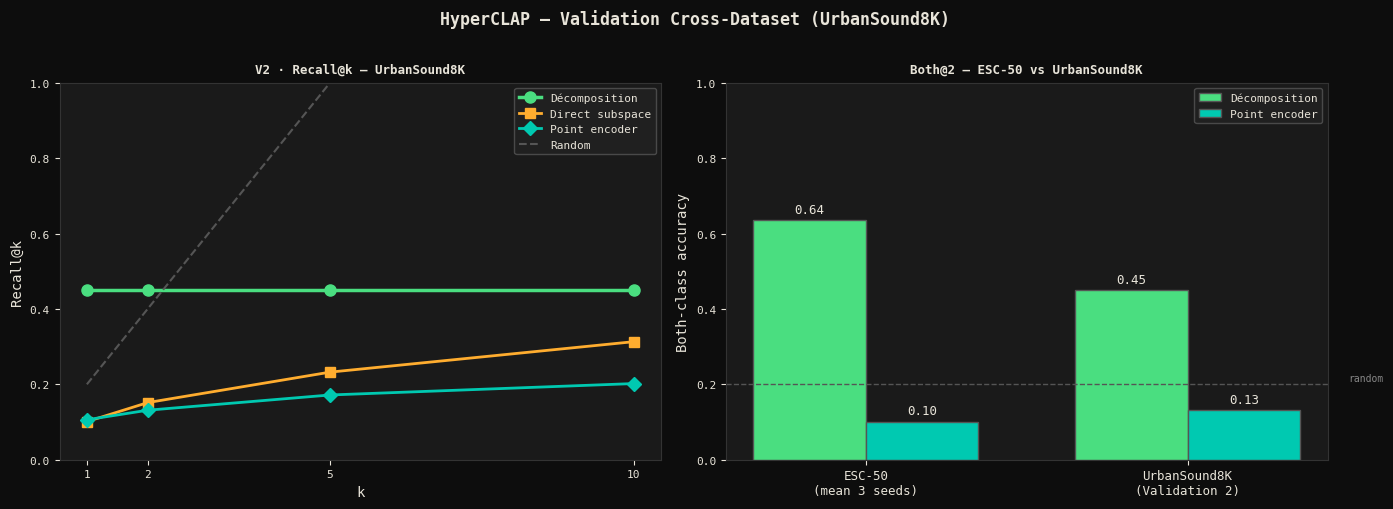

In [30]:
# ── Figure ───────────────────────────────────────────────────────
DARK="#0d0d0d"; LIGHT="#e8e4d9"; GREEN="#4ade80"
CYAN="#00c9b1"; AMBER="#ffad2f"; ROSE="#ff5e78"

plt.rcParams.update({
    "text.color":LIGHT, "axes.labelcolor":LIGHT,
    "xtick.color":LIGHT, "ytick.color":LIGHT,
    "axes.edgecolor":"#333333", "font.family":"monospace"})

def ax_style(ax, title):
    ax.set_facecolor("#1a1a1a")
    ax.set_title(title, color=LIGHT, fontsize=9, pad=7, fontweight="bold")
    ax.tick_params(colors=LIGHT, labelsize=8)
    ax.spines[:].set_color("#333333")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(DARK)

ax = axes[0]; ax_style(ax, "V2 · Recall@k — UrbanSound8K")
ax.plot(KS, [recalls[k]["decomp"] for k in KS], "o-", color=GREEN, lw=2.5, ms=8, label="Décomposition")
ax.plot(KS, [recalls[k]["direct"] for k in KS], "s-", color=AMBER, lw=2,   ms=7, label="Direct subspace")
ax.plot(KS, [recalls[k]["pt"]     for k in KS], "D-", color=CYAN,  lw=2,   ms=7, label="Point encoder")
ax.plot(KS, [2*k/N_CLASSES for k in KS], "--", color="#555", lw=1.5, label="Random")
ax.set_xlabel("k"); ax.set_ylabel("Recall@k")
ax.set_xticks(KS); ax.set_ylim(0, 1.0)
ax.legend(fontsize=8, facecolor="#222", edgecolor="#555", labelcolor=LIGHT)

ax2 = axes[1]; ax_style(ax2, "Both@2 — ESC-50 vs UrbanSound8K")
datasets = ["ESC-50\n(mean 3 seeds)", "UrbanSound8K\n(Validation 2)"]
dv = [ESC50_DECOMP, v2_decomp]
pv = [ESC50_PT,     v2_pt]
x = np.arange(2); w = 0.35
ax2.bar(x-w/2, dv, w, color=GREEN, edgecolor="#555", label="Décomposition")
ax2.bar(x+w/2, pv, w, color=CYAN,  edgecolor="#555", label="Point encoder")
ax2.axhline(2/N_CLASSES, color="#555", ls="--", lw=1)
ax2.text(1.5, 2/N_CLASSES + 0.01, "random", color="#888", fontsize=7)
ax2.set_xticks(x); ax2.set_xticklabels(datasets, fontsize=9)
ax2.set_ylabel("Both-class accuracy"); ax2.set_ylim(0, 1.0)
ax2.legend(fontsize=8, facecolor="#222", edgecolor="#555", labelcolor=LIGHT)
for i_, (d, p) in enumerate(zip(dv, pv)):
    ax2.text(i_-w/2, d+0.02, f"{d:.2f}", ha="center", color=LIGHT, fontsize=9)
    ax2.text(i_+w/2, p+0.02, f"{p:.2f}", ha="center", color=LIGHT, fontsize=9)

fig.suptitle("HyperCLAP — Validation Cross-Dataset (UrbanSound8K)",
             color=LIGHT, fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("/kaggle/working/hyperclap_urban.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
print("Figure saved → hyperclap_urban.png")
plt.show()

In [31]:
# ── Verdict final ────────────────────────────────────────────────
print("\n" + "═" * 65)
print("VALIDATION 2 — VERDICT FINAL (UrbanSound8K)")
print("═" * 65)
print(f"""
  Dataset      : UrbanSound8K ({N_reduced} clips, {N_CLASSES} classes)
  SR           : {SR_TARGET} Hz (uniforme)
  Queries      : {n_q}

  Both-class accuracy (@2):
    Décomposition  : {v2_decomp:.4f}
    Point encoder  : {v2_pt:.4f}
    Random baseline: {2/N_CLASSES:.4f}
    Ratio          : {v2_decomp/(v2_pt+1e-8):.1f}×

  Comparaison cross-dataset :
    ESC-50 (mean 3 seeds) : {ESC50_DECOMP:.4f} décomp / {ESC50_PT:.4f} point  ({ESC50_DECOMP/ESC50_PT:.1f}×)
    UrbanSound8K          : {v2_decomp:.4f} décomp / {v2_pt:.4f} point  ({v2_decomp/(v2_pt+1e-8):.1f}×)

  Généralisation cross-dataset : {'✓ OUI — mécanisme tient sur dataset différent' if generalizes else '✗ NON — voir discussion'}
""")


═════════════════════════════════════════════════════════════════
VALIDATION 2 — VERDICT FINAL (UrbanSound8K)
═════════════════════════════════════════════════════════════════

  Dataset      : UrbanSound8K (400 clips, 10 classes)
  SR           : 22050 Hz (uniforme)
  Queries      : 396

  Both-class accuracy (@2):
    Décomposition  : 0.4495
    Point encoder  : 0.1313
    Random baseline: 0.2000
    Ratio          : 3.4×

  Comparaison cross-dataset :
    ESC-50 (mean 3 seeds) : 0.6352 décomp / 0.1002 point  (6.3×)
    UrbanSound8K          : 0.4495 décomp / 0.1313 point  (3.4×)

  Généralisation cross-dataset : ✓ OUI — mécanisme tient sur dataset différent

